In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-09-11 03:35:49.616233: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 03:35:49.981886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-11 03:35:54.300884: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = "dataset/10p/all/kernel3/"

In [4]:
# Parameters
datasetPath = "dataset/10p/all/kernel3/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-09-11 03:36:07.723778: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-11 03:36:07.724881: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmpep1jzmrr as temporary training directory


Reading training dataset...


Training dataset read in 0:00:04.138910. Found 29597 examples.


Training model...


[INFO 26-09-11 03:36:17.0839 UTC kernel.cc:1233] Loading model from path /tmp/tmpep1jzmrr/model/ with prefix 4c70bb2c49bb4261


Model trained in 0:00:03.749617


Compiling model...


[INFO 26-09-11 03:36:17.3099 UTC decision_forest.cc:734] Model loaded with 300 root(s), 193698 node(s), and 93 input feature(s).
[INFO 26-09-11 03:36:17.3100 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-09-11 03:36:17.3100 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 46.9 s, sys: 747 ms, total: 47.7 s
Wall time: 11.9 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

1/5 [=====>........................] - ETA: 12s - loss: 0.0000e+00 - accuracy: 0.9950

4/5 [=======================>......] - ETA: 0s - loss: 0.0000e+00 - accuracy: 0.9955 

5/5 [==============================] - 3s 19ms/step - loss: 0.0000e+00 - accuracy: 0.9952



loss: 0.0000
accuracy: 0.9952


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (93):
	10Percentile
	90Percentile
	Autocorrelation
	Busyness
	ClusterProminence
	ClusterShade
	ClusterTendency
	Coarseness
	Complexity
	Contrast
	Contrast.1
	Correlation
	DependenceEntropy
	DependenceNonUniformity
	DependenceNonUniformityNormalized
	DependenceVariance
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Energy
	Entropy
	GrayLevelNonUniformity
	GrayLevelNonUniformity.1
	GrayLevelNonUniformity.2
	GrayLevelNonUniformityNormalized
	GrayLevelNonUniformityNormalized.1
	GrayLevelVariance
	GrayLevelVariance.1
	GrayLevelVariance.2
	HighGrayLevelEmphasis
	HighGrayLevelRunEmphasis
	HighGrayLevelZoneEmphasis
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InterquartileRange
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	Kurtosis
	LargeAreaEmphasis
	LargeAreaHighGrayLevelEmphasis
	LargeAreaLowGrayLevelEmphasis
	LargeDependenceEmphasis
	LargeDependenceHighGrayLevelEmphasis
	LargeDependenceLowGrayLevelEmph

In [11]:
# Model features
model.make_inspector().features()

["10Percentile" (1; #0),
 "90Percentile" (1; #1),
 "Autocorrelation" (1; #2),
 "Busyness" (1; #3),
 "ClusterProminence" (1; #4),
 "ClusterShade" (1; #5),
 "ClusterTendency" (1; #6),
 "Coarseness" (1; #7),
 "Complexity" (1; #8),
 "Contrast" (1; #9),
 "Contrast.1" (1; #10),
 "Correlation" (1; #11),
 "DependenceEntropy" (1; #12),
 "DependenceNonUniformity" (1; #13),
 "DependenceNonUniformityNormalized" (1; #14),
 "DependenceVariance" (1; #15),
 "DifferenceAverage" (1; #16),
 "DifferenceEntropy" (1; #17),
 "DifferenceVariance" (1; #18),
 "Energy" (1; #19),
 "Entropy" (1; #20),
 "GrayLevelNonUniformity" (1; #21),
 "GrayLevelNonUniformity.1" (1; #22),
 "GrayLevelNonUniformity.2" (1; #23),
 "GrayLevelNonUniformityNormalized" (1; #24),
 "GrayLevelNonUniformityNormalized.1" (1; #25),
 "GrayLevelVariance" (1; #26),
 "GrayLevelVariance.1" (1; #27),
 "GrayLevelVariance.2" (1; #28),
 "HighGrayLevelEmphasis" (1; #29),
 "HighGrayLevelRunEmphasis" (1; #30),
 "HighGrayLevelZoneEmphasis" (1; #31),
 "Id"

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("LongRunHighGrayLevelEmphasis" (1; #51),
   0.12337134285008629),
  ("GrayLevelNonUniformity.2" (1; #23), 0.10587084775517704),
  ("LargeDependenceHighGrayLevelEmphasis" (1; #48), 0.10328007629677433),
  ("Coarseness" (1; #7), 0.10233106720919312),
  ("90Percentile" (1; #1), 0.10125488796500243),
  ("Median" (1; #61), 0.10090420658356405),
  ("HighGrayLevelZoneEmphasis" (1; #31), 0.10011630436675041),
  ("Idn" (1; #35), 0.09939408245512392),
  ("Busyness" (1; #3), 0.09924005080590377),
  ("Maximum" (1; #57), 0.09902745120431328),
  ("Mean" (1; #59), 0.09897987492908417),
  ("TotalEnergy" (1; #87), 0.09840970943016332),
  ("Autocorrelation" (1; #2), 0.09793239366662825),
  ("Idmn" (1; #34), 0.09782475691616098),
  ("HighGrayLevelEmphasis" (1; #29), 0.09780805288712591),
  ("RootMeanSquared" (1; #65), 0.09736912676371888),
  ("Energy" (1; #19), 0.0972009165257087),
  ("JointAverage" (1; #40), 0.09699811609440992),
  ("SumAverage" (1; #84), 0.09611831750080385),
 

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=29597, accuracy=0.899273544577225, loss=0.28319371002684723, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

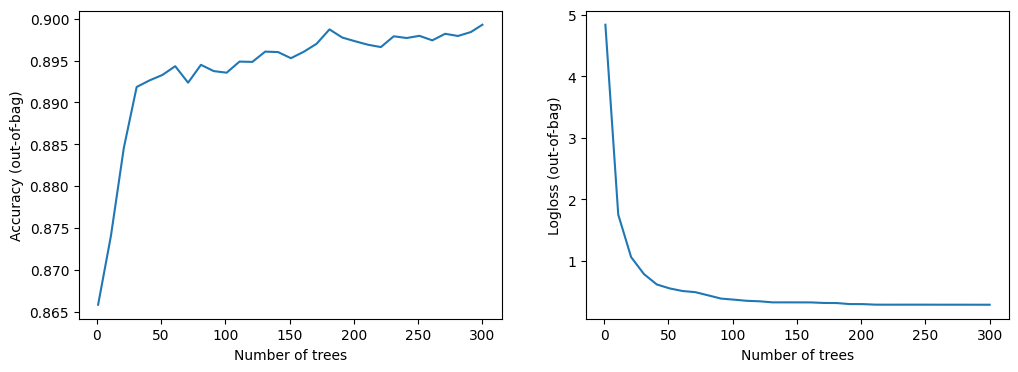

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

1/5 [=====>........................] - ETA: 0s

4/5 [=======================>......] - ETA: 0s

5/5 [==============================] - 0s 18ms/step


The ROC AUC score is 0.99901


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

1/9 [==>...........................] - ETA: 1s

3/9 [=========>....................] - ETA: 0s

6/9 [===================>..........] - ETA: 0s

9/9 [==============================] - ETA: 0s

9/9 [==============================] - 0s 22ms/step


Sklearn binary metrics:
accuracy: 0.9675
precision: 0.9003
recall: 0.7565
f1: 0.8222
mcc: 0.8081
roc_auc: 0.9757
pr_auc: 0.9064
log_loss: 0.0998
brier_score: 0.0233

Confusion matrix:
 [[7937   74]
 [ 215  668]]

Classification report:
               precision    recall  f1-score   support

           0     0.9736    0.9908    0.9821      8011
           1     0.9003    0.7565    0.8222       883

    accuracy                         0.9675      8894
   macro avg     0.9369    0.8736    0.9021      8894
weighted avg     0.9663    0.9675    0.9662      8894

